In [56]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat, savemat

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import Dataset
from torchvision import models

In [58]:
from art.attacks.evasion import BasicIterativeMethod
from art.estimators.classification import PyTorchClassifier

In [59]:
DATA_PATH = os.path.join("..", "..", "content", "mnist_original.mat")
MODEL_PATH = os.path.join("..", "..", "models", "resnet18_mnist_surrogate_or.pth")  

In [60]:
EPOCHS = 50
BATCH_SIZE = 64

In [61]:
mnist = loadmat(DATA_PATH)
mnist_data, mnist_label = np.array(mnist["data"].T), np.array(mnist["label"][0].T)

In [62]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [63]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx].reshape(28, 28).astype(np.uint8)
        if self.transform:
            img = self.transform(img)
        label = int(self.labels[idx])
        return img, label

In [64]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

In [65]:
dataset = MNISTDataset(mnist_data, mnist_label, transform=transform)

In [66]:
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)

model.load_state_dict(torch.load(MODEL_PATH))

model = model.to(device)

In [67]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [68]:
classifier = PyTorchClassifier(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    input_shape=(3, 224, 224),
    nb_classes=10,
    device_type=device
)

In [69]:
eps = 0.04
eps_step = eps / 4

In [70]:
ifgsm_attack = BasicIterativeMethod(
    estimator=classifier,
    eps=eps,
    eps_step=eps_step,
    max_iter=EPOCHS,
    targeted=False,
    batch_size=BATCH_SIZE
)

In [71]:
num_samples = 1000
test_indices = random.sample(range(len(dataset)), num_samples)

In [72]:
original_images = []
true_labels = []

for idx in test_indices:
    img, label = dataset[idx]
    original_images.append(img.numpy())
    true_labels.append(label)

original_images = np.array(original_images)
true_labels = np.array(true_labels)

print(f"Original images shape: {original_images.shape}")
print(f"Labels shape: {true_labels.shape}")

Original images shape: (1000, 3, 224, 224)
Labels shape: (1000,)


In [73]:
adversarial_images = ifgsm_attack.generate(x=original_images)

In [74]:
original_predictions = classifier.predict(original_images)
original_accuracy = np.mean(np.argmax(original_predictions, axis=1) == true_labels)

adversarial_predictions = classifier.predict(adversarial_images)
adversarial_accuracy = np.mean(np.argmax(adversarial_predictions, axis=1) == true_labels)

print(f"\nAccuracy on original images: {original_accuracy * 100:.2f}%")
print(f"Accuracy on adversarial images: {adversarial_accuracy * 100:.2f}%")
print(f"Attack success rate: {(1 - adversarial_accuracy) * 100:.2f}%")


Accuracy on original images: 99.70%
Accuracy on adversarial images: 10.60%
Attack success rate: 89.40%


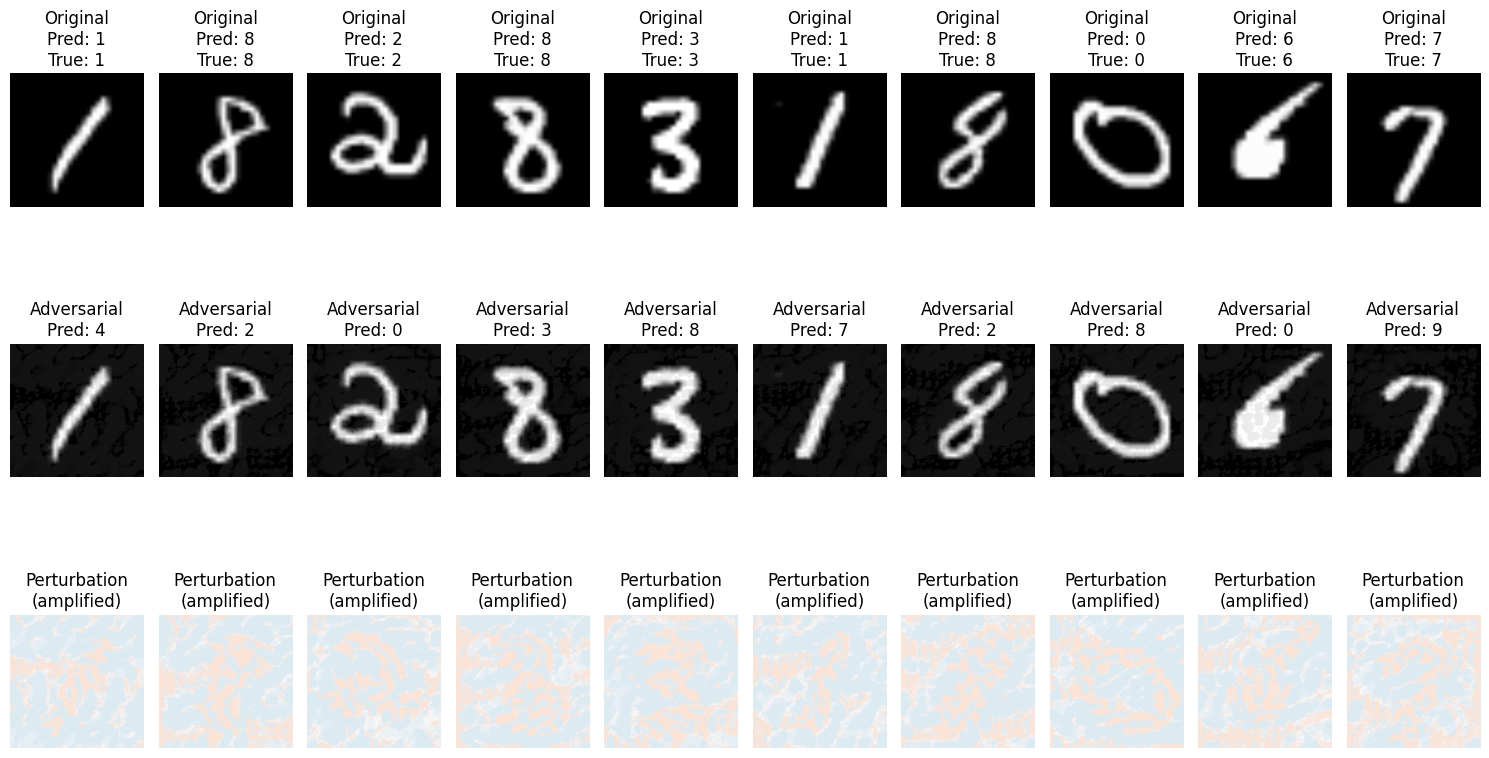

In [75]:
num_display = 10
fig, axes = plt.subplots(3, num_display, figsize=(15, 9))

for i in range(num_display):
    orig_img = original_images[i].transpose(1, 2, 0)
    axes[0, i].imshow(orig_img[:,:,0], cmap='gray')
    axes[0, i].set_title(f'Original\nPred: {np.argmax(original_predictions[i])}\nTrue: {true_labels[i]}')
    axes[0, i].axis('off')
    
    adv_img = adversarial_images[i].transpose(1, 2, 0)
    axes[1, i].imshow(adv_img[:,:,0], cmap='gray')
    axes[1, i].set_title(f'Adversarial\nPred: {np.argmax(adversarial_predictions[i])}')
    axes[1, i].axis('off')
    
    perturbation = (adv_img - orig_img)[:,:,0]
    axes[2, i].imshow(perturbation, cmap='RdBu', vmin=-0.3, vmax=0.3)
    axes[2, i].set_title(f'Perturbation\n(amplified)')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()


In [76]:
perturbations = adversarial_images - original_images
l_inf_norm = np.max(np.abs(perturbations))
l_2_norm = np.mean(np.linalg.norm(perturbations.reshape(len(perturbations), -1), axis=1))

print(f"\nPerturbation Statistics:")
print(f"L∞ norm (max perturbation): {l_inf_norm:.4f}")
print(f"Average L2 norm: {l_2_norm:.4f}")


Perturbation Statistics:
L∞ norm (max perturbation): 0.0400
Average L2 norm: 14.3905


In [77]:
ut_channels=1),
    transforms.ToTensor()
])

for adv_img in adversarial_images:
    adv_img_uint8 = (adv_img.transpose(1, 2, 0) * 255))
ial_examples.size(0), -1).numpy()

labels_np = np.array(true_labels)# # # # # # # # 


In [79]:
output_dir = 'content'
output_filename = 'adversarial_data_1000.mat'
output_path = os.path.join('..', '..', output_dir, output_filename)

os.makedirs(os.path.dirname(output_path), exist_ok=True)

savemat(output_path, {'adversarial_examples': adversarial_examples_flat, 'labels': labels_np})